## Train and asses using traditional ML algorithms

In [2]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, DatasetDict, Dataset
import matplotlib.pyplot as plt
from openai import OpenAI
import random
from collections import Counter
import pickle

# More imports for our traditional machine learning
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [4]:
# more imports for NLP
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess


In [5]:
# More imports for advanced machine learning
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

In [71]:
from testing import Tester

In [7]:
load_dotenv(override=True)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")


In [8]:
hf_token = os.getenv("HF_TOKEN")
login(hf_token, add_to_git_credential=True)
openai = OpenAI()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [9]:
from items import Item

In [10]:
%matplotlib inline

In [11]:
with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)
    

In [16]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

OEM AC Compressor w/A/C Repair Kit For Ford F150 F-150 V8 & Lincoln Mark LT 2007 2008 - BuyAutoParts NEW
As one of the world's largest automotive parts suppliers, our parts are trusted every day by mechanics and vehicle owners worldwide. This A/C Compressor and Components Kit is manufactured and tested to the strictest OE standards for unparalleled performance. Built for trouble-free ownership and 100% visually inspected and quality tested, this A/C Compressor and Components Kit is backed by our 100% satisfaction guarantee. Guaranteed Exact Fit for easy installation 100% BRAND NEW, premium ISO/TS 16949 quality - tested to meet or exceed OEM specifications Engineered for superior durability, backed by industry-leading unlimited-mileage warranty Included in this K

Price is $


In [19]:
import json

In [20]:
for item in train:
    item.feature = json.loads(item.details)

for item in test:
    item.feature = json.loads(item.details)

In [21]:
train[0].feature

{'Brand': 'Delphi',
 'Fit Type': 'Vehicle Specific Fit',
 'Item Dimensions LxWxH': '19.7 x 7.7 x 5.1 inches',
 'Item Weight': '2.2 Pounds',
 'Auto Part Position': 'Unknown',
 'Operation Mode': 'Mechanical',
 'Manufacturer': 'Delphi',
 'Model': 'FUEL PUMP',
 'Product Dimensions': '19.7 x 7.7 x 5.1 inches',
 'Country of Origin': 'USA',
 'Item model number': 'FG0166',
 'Is Discontinued By Manufacturer': 'No',
 'Exterior': 'Painted',
 'Manufacturer Part Number': 'FG0166',
 'OEM Part Number': '25326856, 89060639, A30416, E4061R, MU242',
 'Best Sellers Rank': {'Automotive': 913571,
  'Automotive Replacement Electric Fuel Pumps': 6568},
 'Domestic Shipping': 'Item can be shipped within U.S.',
 'International Shipping': 'This item is not eligible for international shipping.  Learn More',
 'Date First Available': 'August 9, 2006'}

In [24]:
len(train[36].feature)

8

In [27]:
feature_count = Counter()
for item in train:
    for f in item.feature.keys():
        feature_count[f] += 1
    
feature_count.most_common(40)

[('Date First Available', 360062),
 ('Item Weight', 350444),
 ('Manufacturer', 349357),
 ('Brand', 340323),
 ('Best Sellers Rank', 330473),
 ('Item model number', 277573),
 ('Product Dimensions', 262400),
 ('Color', 183794),
 ('Is Discontinued By Manufacturer', 169828),
 ('Manufacturer Part Number', 145092),
 ('Material', 137447),
 ('Country of Origin', 121451),
 ('Style', 77639),
 ('Special Feature', 74709),
 ('Part Number', 74529),
 ('Batteries Required?', 73595),
 ('Package Dimensions', 72900),
 ('Item Dimensions LxWxH', 71385),
 ('Included Components', 67509),
 ('Model', 65144),
 ('Size', 58233),
 ('Item Package Quantity', 58149),
 ('Batteries Included?', 56779),
 ('OEM Part Number', 56062),
 ('Special Features', 53740),
 ('Exterior', 50566),
 ('Power Source', 50256),
 ('Vehicle Service Type', 49420),
 ('Finish Type', 46262),
 ('Voltage', 46036),
 ('Mounting Type', 38043),
 ('Model Name', 37524),
 ('Shape', 34816),
 ('Finish', 31901),
 ('Number of Items', 31871),
 ('Connectivity Te

In [30]:
def get_weight(item):
    weight_str = item.feature.get('Item Weight')
    if weight_str:
        parts = weight_str.split(' ')
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit=="pounds":
            return amount
        elif unit=="ounces":
            return amount / 16
        elif unit=="grams":
            return amount / 453.592
        elif unit=="milligrams":
            return amount / 453592
        elif unit=="kilograms":
            return amount / 0.453592
        elif unit=="hundredths" and parts[2].lower()=="pounds":
            return amount / 100
        else:
            print(weight_str)
    return None

In [31]:
weights = [get_weight(t) for t in train]
weights = [w for w in weights if w]

In [32]:
average_weight = sum(weights)/len(weights)
average_weight

13.570552370295237

In [33]:
def get_weight_with_default(item):
    weight = get_weight(item)
    return weight or average_weight

In [34]:
def get_rank(item):
    rank_dict = item.feature.get("Best Sellers Rank")
    if rank_dict:
        ranks = rank_dict.values()
        return sum(ranks)/len(ranks)
    return None

In [35]:
ranks = [get_rank(t) for t in train]
ranks = [r for r in ranks if r]
average_rank = sum(ranks)/len(ranks)
average_rank

380638.258828072

In [36]:
def get_rank_with_default(item):
    rank = get_rank(item)
    return rank or average_rank

In [37]:
def get_text_length(item):
    return len(item.test_prompt())

In [38]:
# investigate the brands

brands = Counter()
for t in train:
    brand = t.feature.get("Brand")
    if brand:
        brands[brand]+=1

# Look at most common 40 brands

brands.most_common(40)

[('HP', 5500),
 ('Power Stop', 3594),
 ('Dell', 3254),
 ('Detroit Axle', 2734),
 ('Lenovo', 2441),
 ('Dorman', 2116),
 ('SAMSUNG', 1772),
 ('BUYAUTOPARTS!', 1715),
 ('ACDelco', 1609),
 ('Evan Fischer', 1415),
 ('ASUS', 1387),
 ('Sony', 1282),
 ('Canon', 1201),
 ('Callahan BRAKE PARTS', 1154),
 ('Kohler', 1152),
 ('CURT', 1120),
 ('R1 Concepts', 1054),
 ('Rareelectrical', 966),
 ('Coverking', 941),
 ('Garage-Pro', 888),
 ('Kingston Brass', 852),
 ('Spectra Premium', 834),
 ('Moen', 829),
 ('Auto Dynasty', 824),
 ('WeatherTech', 822),
 ('DELTA FAUCET', 811),
 ('Generic', 793),
 ('Apple', 783),
 ('Cardone', 765),
 ('APS', 763),
 ('K&N', 758),
 ('GM', 743),
 ('Walker', 732),
 ('EBC Brakes', 717),
 ('AKKON', 646),
 ('SPEC-D TUNING', 626),
 ('TYC', 626),
 ('Covercraft', 618),
 ('Intel', 610),
 ('A-Premium', 607)]

In [39]:
TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel"]


In [55]:
def is_top_electronics_brand(item):
    brand = item.feature.get("Brand")
    return brand and brand.lower() in TOP_ELECTRONICS_BRANDS

In [52]:
for i in train[:100]:
    best = i.feature.get("Best Sellers Rank")
    if(best):
        print(best)
        

{'Automotive': 913571, 'Automotive Replacement Electric Fuel Pumps': 6568}
{'Automotive': 1527070, 'Automotive Performance Brake Kits': 162}
{'Appliances': 3506, 'Cooktops': 356}
{'Tools & Home Improvement': 801942, 'Cabinet & Furniture Knobs': 7165}
{'Computers & Accessories': 36776, 'Computer Routers': 1200}
{'Electronics': 106294, 'Vehicle Backup Cameras': 899}
{'Tools & Home Improvement': 26069, 'Door Closers': 27}
{'Fixed-mount CB Radios': 281}
{'Tools & Home Improvement': 154397, 'Power Concrete Mixers': 61}
{'Tools & Home Improvement': 133131, 'Side-Cutting Pliers': 218}
{'Automotive': 1424595, 'Automotive Replacement Air Filters': 14543}
{'Tools & Home Improvement': 241831, 'Household Ventilation Fans': 589}
{'Automotive': 479528, 'Automotive Headlight Assemblies': 6170}
{'Automotive': 412702, 'Motorcycle & Powersports Helmets': 1166}
{'Toys & Games': 197813, 'Toy Foods': 524, 'Preschool Kitchen Sets & Play Food': 982}
{'Digital Camera Battery Grips': 86}
{'Computer Memory': 18

In [53]:
def get_features(item):
    return {
        "weight": get_weight_with_default(item),
        "rank": get_rank_with_default(item),
        "text_length": get_text_length(item),
        "is_top_electronics_brand": 1 if is_top_electronics_brand(item) else 0
    }

In [56]:
get_features(train[0])

{'weight': 2.2,
 'rank': 460069.5,
 'text_length': 748,
 'is_top_electronics_brand': 0}

In [57]:
# A utility function to convert our features into a pandas dataframe

def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test[:250])

In [58]:
test_df

,weight,rank,text_length,is_top_electronics_brand,price
0,19.300000,674674.500000,832,0,374.41
1,5.000000,496362.000000,676,0,225.11
2,1.360000,74004.000000,666,0,61.68
3,5.240000,42424.666667,789,1,599.99
4,13.570552,380638.258828,761,0,16.99
...,...,...,...,...,...
245,13.570552,3261.500000,798,0,193.06
246,6.090000,73761.666667,698,0,249.99
247,0.250000,380638.258828,736,0,64.12
248,3.430000,283423.500000,575,0,114.99


In [64]:
np.random.seed(42)

feature_columns = ['weight', 'rank', 'text_length', 'is_top_electronics_brand']

X_train = train_df[feature_columns]
y_train = train_df["price"]
X_test = test_df[feature_columns]
y_test = test_df["price"]

model = LinearRegression()
model.fit(X_train, y_train)

for feature_column, coef in zip(feature_columns, model.coef_):
    print(f"{feature_column}: {coef}")

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")


weight: 0.264232186295733
rank: 5.197480233116726e-05
text_length: 0.007609328351319949
is_top_electronics_brand: 198.1425428320687
Mean Squared Error: 33034.336771968
R-squared Score: 0.090915711948652


In [69]:
# Function to predict price for a new item

def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

1: Guess: $228.68 Truth: $374.41 Error: $145.73 SLE: 0.24 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $214.45 Truth: $225.11 Error: $10.66 SLE: 0.00 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $191.46 Truth: $61.68 Error: $129.78 SLE: 1.26 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $389.92 Truth: $599.99 Error: $210.07 SLE: 0.18 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $211.35 Truth: $16.99 Error: $194.36 SLE: 6.09 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $211.42 Truth: $31.99 Error: $179.43 SLE: 3.47 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $190.88 Truth: $101.79 Error: $89.09 SLE: 0.39 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $190.14 Truth: $289.00 Error: $98.86 SLE: 0.17 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $220.89 Truth: $635.86 Error: $414.97 SLE: 1.11 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $199.88 Truth: $65.99 Error: $133.89 S

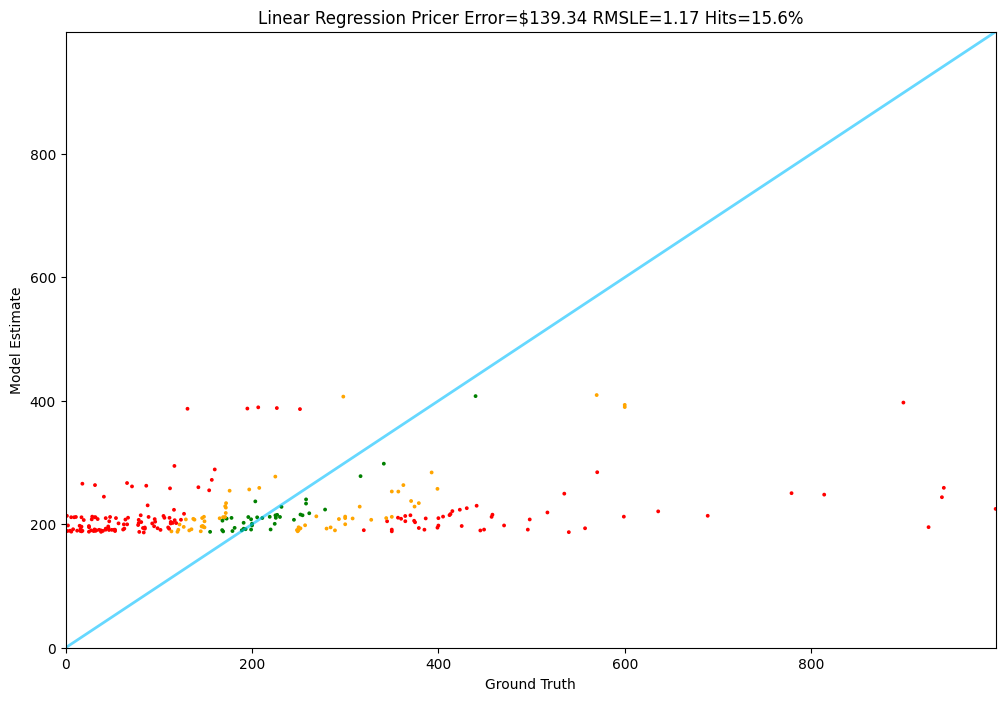

In [75]:
Tester.test(linear_regression_pricer, test)

In [76]:
prices = np.array([float(item.price) for item in train])
documents = [item.test_prompt() for item in train]

In [77]:
np.random.seed(42)
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(documents)
regressor = LinearRegression()
regressor.fit(X, prices) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
def bow_lr_pricer(item):
    x = vectorizer.transform([item.test_prompt()])
    return max(regressor.predict(x)[0], 0)

1: Guess: $296.58 Truth: $374.41 Error: $77.83 SLE: 0.05 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $165.14 Truth: $225.11 Error: $59.97 SLE: 0.09 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $162.26 Truth: $61.68 Error: $100.58 SLE: 0.92 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $326.15 Truth: $599.99 Error: $273.84 SLE: 0.37 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $51.69 Truth: $16.99 Error: $34.70 SLE: 1.15 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $74.06 Truth: $31.99 Error: $42.07 SLE: 0.68 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $344.83 Truth: $101.79 Error: $243.04 SLE: 1.47 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $241.39 Truth: $289.00 Error: $47.61 SLE: 0.03 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $404.57 Truth: $635.86 Error: $231.29 SLE: 0.20 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $111.13 Truth: $65.99 Error: $45.14 SLE: 0

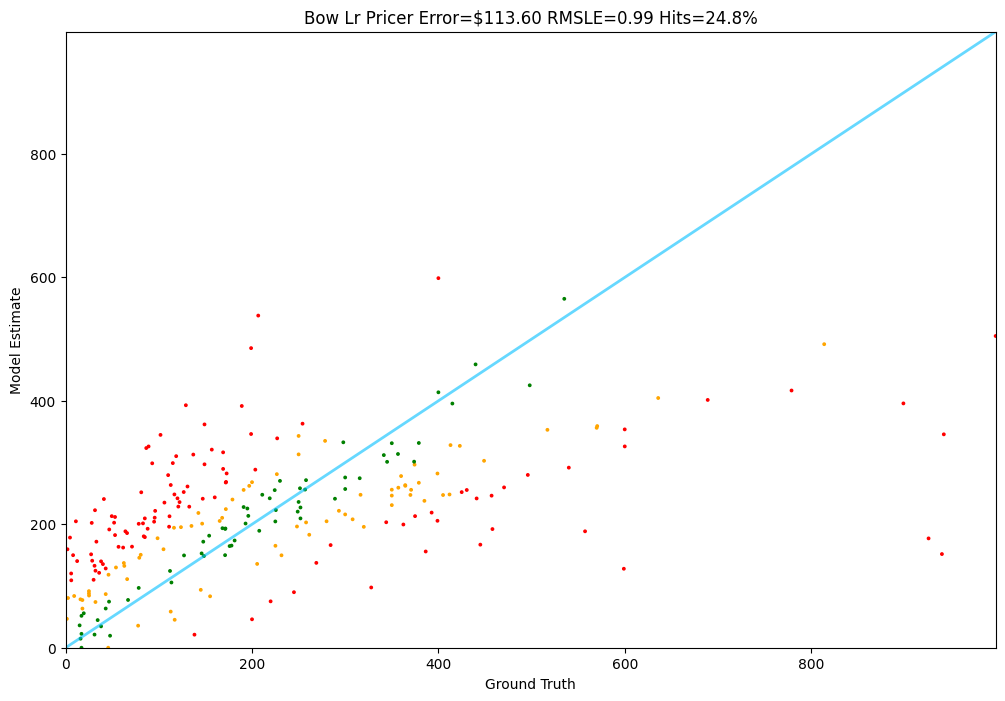

In [79]:
Tester.test(bow_lr_pricer, test)

In [82]:
# The amazing word2vec model, implemented in gensim NLP library

np.random.seed(42)

# Preprocess the documents
processed_docs = [simple_preprocess(doc) for doc in documents]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=processed_docs, vector_size=400, window=5, min_count=1, workers=8)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [84]:
# This step of averaging vectors across the document is a weakness in our approach

def document_vector(doc):
    doc_words = simple_preprocess(doc)
    word_vectors = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(w2v_model.vector_size)

# Create feature matrix
X_w2v = np.array([document_vector(doc) for doc in documents])

In [85]:
# Run Linear Regression on word2vec

word2vec_lr_regressor = LinearRegression()
word2vec_lr_regressor.fit(X_w2v, prices)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
def word2vec_lr_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, word2vec_lr_regressor.predict([doc_vector])[0])

1: Guess: $246.79 Truth: $374.41 Error: $127.62 SLE: 0.17 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $143.34 Truth: $225.11 Error: $81.77 SLE: 0.20 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $154.12 Truth: $61.68 Error: $92.44 SLE: 0.82 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $359.59 Truth: $599.99 Error: $240.40 SLE: 0.26 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $124.99 Truth: $16.99 Error: $108.00 SLE: 3.79 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $0.00 Truth: $31.99 Error: $31.99 SLE: 12.22 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $287.10 Truth: $101.79 Error: $185.31 SLE: 1.06 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $260.93 Truth: $289.00 Error: $28.07 SLE: 0.01 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $346.39 Truth: $635.86 Error: $289.47 SLE: 0.37 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $135.36 Truth: $65.99 Error: $69.37 SLE:

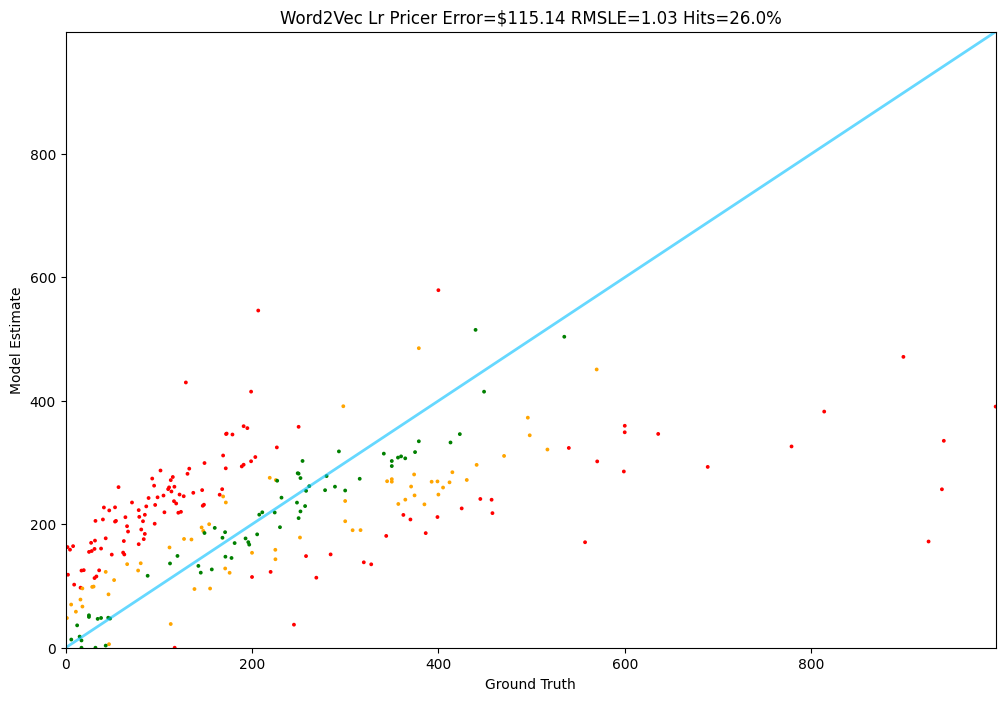

In [88]:
Tester.test(word2vec_lr_pricer, test)

In [89]:
# Support Vector Machines

np.random.seed(42)
svr_regressor = LinearSVR()

svr_regressor.fit(X_w2v, prices)

,epsilon,0.0
,tol,0.0001
,C,1.0
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,None
,max_iter,1000


In [90]:
def svr_pricer(item):
    np.random.seed(42)
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(float(svr_regressor.predict([doc_vector])[0]),0)

1: Guess: $248.61 Truth: $374.41 Error: $125.80 SLE: 0.17 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $175.53 Truth: $225.11 Error: $49.58 SLE: 0.06 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $132.28 Truth: $61.68 Error: $70.60 SLE: 0.57 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $302.25 Truth: $599.99 Error: $297.74 SLE: 0.47 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $86.46 Truth: $16.99 Error: $69.47 SLE: 2.50 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $0.00 Truth: $31.99 Error: $31.99 SLE: 12.22 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $245.48 Truth: $101.79 Error: $143.69 SLE: 0.76 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $191.15 Truth: $289.00 Error: $97.85 SLE: 0.17 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $285.52 Truth: $635.86 Error: $350.34 SLE: 0.64 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $138.41 Truth: $65.99 Error: $72.42 SLE: 0

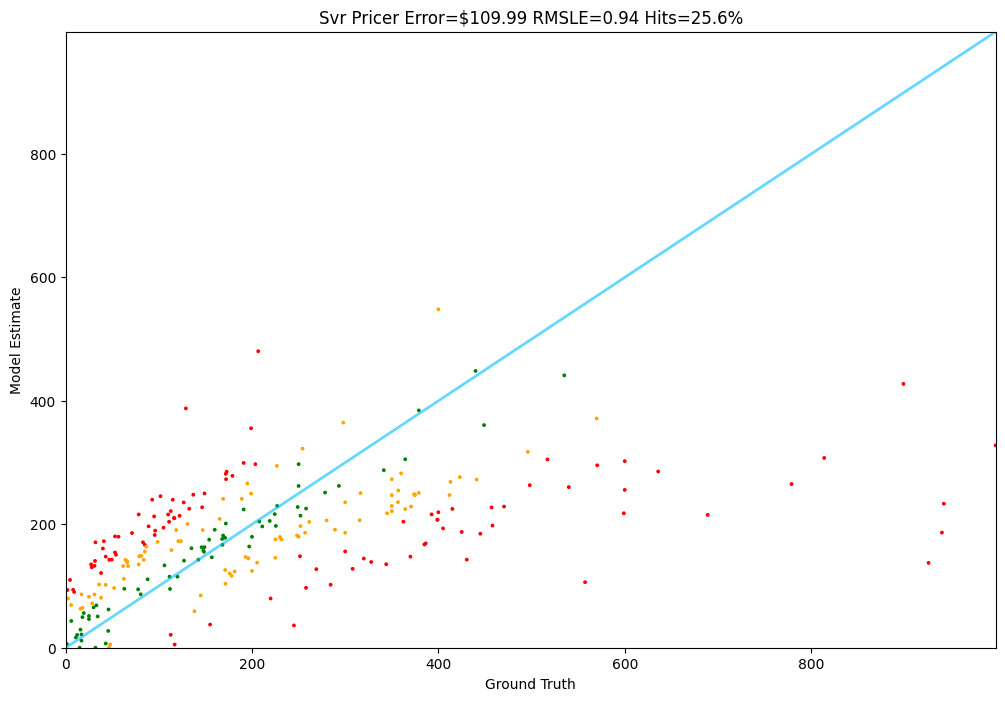

In [96]:
Tester.test(svr_pricer, test)

In [93]:
# And the powerful Random Forest regression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4)
rf_model.fit(X_w2v, prices)

KeyboardInterrupt: 

In [94]:
def random_forest_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, rf_model.predict([doc_vector])[0])

In [95]:
Tester.test(random_forest_pricer, test)

IndexError: list index out of range